In [173]:
import torch

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

# This is your GPU on Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.12.0
MPS available: True
Using device: mps


In [174]:
import pandas as pd

# Load directly from web
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.head())

print(df.isnull().sum())
print(df.dtypes)

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [175]:

df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df.isnull().sum())
print(df.head())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare
0         0       3    0  22.0      1      0   7.2500
1         1       1    1  38.0      1      0  71.2833
2         1       3    1  26.0      0      0   7.9250
3         1       1    1  35.0      1      0  53.1000
4         0       3    0  35.0      0      0   8.0500


In [176]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df.drop('Survived', axis=1).values
y = df['Survived'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: torch.Size([712, 6])
Test shape: torch.Size([179, 6])


In [177]:
import torch.nn as nn


class TitanicModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(6, 8)   
        self.bn1 = nn.BatchNorm1d(8)
        self.layer2 = nn.Linear(8, 4)   
        self.bn2 = nn.BatchNorm1d(4)
        self.layer3 = nn.Linear(4, 1) 
        self.bn3 = nn.BatchNorm1d(1)  
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.layer1(x))))
        x = self.dropout(self.relu(self.bn2(self.layer2(x))))
        x = self.sigmoid(self.layer3(x))
        return x


model = TitanicModel().to(device)
print(model)

TitanicModel(
  (layer1): Linear(in_features=6, out_features=8, bias=True)
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer2): Linear(in_features=8, out_features=4, bias=True)
  (bn2): BatchNorm1d(4, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (layer3): Linear(in_features=4, out_features=1, bias=True)
  (bn3): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)


In [178]:
loss_fn = nn.BCELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [179]:
epochs = 500

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(X_train).squeeze()
    loss = loss_fn(outputs, y_train)
    
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/500], Loss: 0.5753
Epoch [200/500], Loss: 0.5294
Epoch [300/500], Loss: 0.5154
Epoch [400/500], Loss: 0.4920
Epoch [500/500], Loss: 0.4904


In [180]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test).squeeze()
    predicted = (test_outputs > 0.5).float()
    accuracy = (predicted == y_test).float().mean()
    print(f"Test Accuracy: {accuracy.item():.4f}")

Test Accuracy: 0.8324


In [181]:
# # Save
# torch.save(model.state_dict(), 'titanic_model.pth')
# print("Model saved!")

# # Load it back
# loaded_model = TitanicModel().to(device)
# loaded_model.load_state_dict(torch.load('titanic_model.pth'))
# print("Model loaded!")

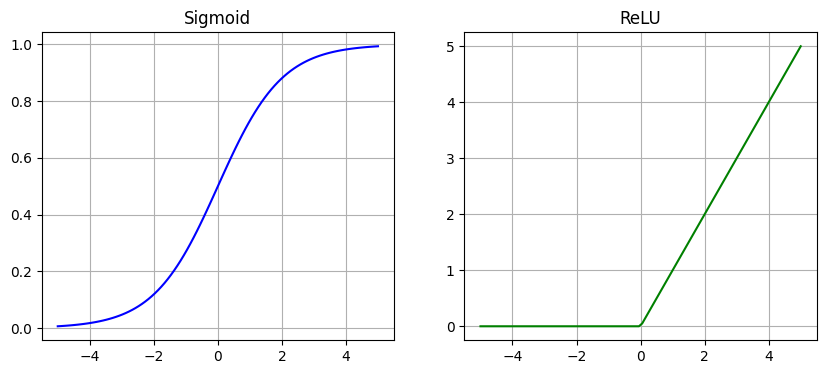

In [182]:
import torch
import matplotlib.pyplot as plt
import numpy as np

x = torch.linspace(-5, 5, 100)

sigmoid = torch.sigmoid(x)
relu = torch.relu(x)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), sigmoid.numpy(), color='blue')
plt.title('Sigmoid')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x.numpy(), relu.numpy(), color='green')
plt.title('ReLU')
plt.grid(True)

plt.show()

In [183]:

loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # start higher
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

for epoch in range(500):
    model.train()
    
    y_pred = model(X_train)
    loss = loss_fn(y_pred.squeeze(), y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()  # update learning rate
    
    if epoch % 100 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}, LR: {current_lr}")

Epoch 0, Loss: 0.4852, LR: 0.01
Epoch 100, Loss: 0.4560, LR: 0.005
Epoch 200, Loss: 0.4648, LR: 0.0025
Epoch 300, Loss: 0.4535, LR: 0.00125
Epoch 400, Loss: 0.4795, LR: 0.000625
